In [32]:
!pip install py7zr


In [33]:
import py7zr

archive_path = '/content/DataCoSupplyChainDataset.7z'
extract_path = '/content/DataCoSupplyChainDataset'  # folder to extract files

with py7zr.SevenZipFile(archive_path, mode='r') as z:
    z.extractall(path=extract_path)

print("Extraction completed!")


Extraction completed!


In [34]:
import pandas as pd

csv_path = '/content/DataCoSupplyChainDataset/DataCoSupplyChainDataset.csv'
df = pd.read_csv(csv_path, encoding='latin1')

print(f"Dataset loaded: {df.shape[0]} rows, {df.shape[1]} columns")
df.head()


Dataset loaded: 180519 rows, 53 columns


,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2/3/2018 22:56,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/18/2018 12:27,Standard Class
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/17/2018 12:06,Standard Class
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,Los Angeles,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/16/2018 11:45,Standard Class
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/15/2018 11:24,Standard Class


In [35]:
# List all columns
print("All columns in the dataset:")
for i, col in enumerate(df.columns, 1):
    print(f"{i}. {col}")


All columns in the dataset:
1. Type
2. Days for shipping (real)
3. Days for shipment (scheduled)
4. Benefit per order
5. Sales per customer
6. Delivery Status
7. Late_delivery_risk
8. Category Id
9. Category Name
10. Customer City
11. Customer Country
12. Customer Email
13. Customer Fname
14. Customer Id
15. Customer Lname
16. Customer Password
17. Customer Segment
18. Customer State
19. Customer Street
20. Customer Zipcode
21. Department Id
22. Department Name
23. Latitude
24. Longitude
25. Market
26. Order City
27. Order Country
28. Order Customer Id
29. order date (DateOrders)
30. Order Id
31. Order Item Cardprod Id
32. Order Item Discount
33. Order Item Discount Rate
34. Order Item Id
35. Order Item Product Price
36. Order Item Profit Ratio
37. Order Item Quantity
38. Sales
39. Order Item Total
40. Order Profit Per Order
41. Order Region
42. Order State
43. Order Status
44. Order Zipcode
45. Product Card Id
46. Product Category Id
47. Product Description
48. Product Image
49. Produ

In [36]:
cols_to_drop = [
    'Customer Email', 'Customer Password', 'Customer Fname', 'Customer Lname', 'Customer Id',
    'Order Id', 'Order Item Id', 'Order Customer Id', 'Product Card Id', 'Product Category Id', 'Category Id',
    'Product Image', 'Product Description', 'Customer Street', 'Customer Zipcode', 'Order Zipcode', 'Product Status'
]

df_clean = df.drop(columns=cols_to_drop)
print(f"Columns remaining: {df_clean.shape[1]}")
print(df_clean.columns.tolist())


Columns remaining: 36
['Type', 'Days for shipping (real)', 'Days for shipment (scheduled)', 'Benefit per order', 'Sales per customer', 'Delivery Status', 'Late_delivery_risk', 'Category Name', 'Customer City', 'Customer Country', 'Customer Segment', 'Customer State', 'Department Id', 'Department Name', 'Latitude', 'Longitude', 'Market', 'Order City', 'Order Country', 'order date (DateOrders)', 'Order Item Cardprod Id', 'Order Item Discount', 'Order Item Discount Rate', 'Order Item Product Price', 'Order Item Profit Ratio', 'Order Item Quantity', 'Sales', 'Order Item Total', 'Order Profit Per Order', 'Order Region', 'Order State', 'Order Status', 'Product Name', 'Product Price', 'shipping date (DateOrders)', 'Shipping Mode']


# Check for Missing Values

In [37]:
# Check missing values
missing_pct = (df_clean.isna().mean() * 100).round(2)
print("Missing values (%):")
print(missing_pct[missing_pct > 0])

#  impute numeric with mean, categorical with mode
num_cols = df_clean.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = df_clean.select_dtypes(include=['object']).columns.tolist()

# Mean imputation for numeric
for c in num_cols:
    if df_clean[c].isna().any():
        df_clean[c] = df_clean[c].fillna(df_clean[c].mean())

# Mode imputation for categorical
for c in cat_cols:
    if df_clean[c].isna().any():
        mode_val = df_clean[c].mode(dropna=True)[0]
        df_clean[c] = df_clean[c].fillna(mode_val)

# Safety: drop any leftover NA
before_drop = df_clean.shape[0]
df_clean = df_clean.dropna()
after_drop = df_clean.shape[0]
print(f"Dropped {before_drop - after_drop} rows with leftover NA")


Missing values (%):
Series([], dtype: float64)
Dropped 0 rows with leftover NA


In [ ]:
# Keep only categorical columns with <=50 unique values
low_card_threshold = 50
low_card_cat_cols = [c for c in cat_cols if df_clean[c].nunique() <= low_card_threshold]
high_card_cat_cols = [c for c in cat_cols if df_clean[c].nunique() > low_card_threshold]

# Drop high-cardinality categorical columns 
if high_card_cat_cols:
    print(f"Dropping high-cardinality categorical columns (> {low_card_threshold} uniques): {high_card_cat_cols}")
    df_clean = df_clean.drop(columns=high_card_cat_cols)

# One-hot encode remaining low-cardinality categorical columns
df_clean = pd.get_dummies(df_clean, columns=low_card_cat_cols, drop_first=True)
print(f"Columns after encoding: {df_clean.shape[1]}")


Dropping high-cardinality categorical columns (> 50 uniques): ['Customer City', 'Order City', 'Order Country', 'order date (DateOrders)', 'Order State', 'Product Name', 'shipping date (DateOrders)']
Columns after encoding: 168


# Handle Date Columns

In [39]:
date_cols = [c for c in df_clean.columns if 'date' in c.lower()]

for c in date_cols:
    dt = pd.to_datetime(df_clean[c], errors='coerce', infer_datetime_format=True)
    df_clean[f'{c}__year'] = dt.dt.year
    df_clean[f'{c}__month'] = dt.dt.month
    df_clean[f'{c}__day'] = dt.dt.day
    df_clean[f'{c}__weekday'] = dt.dt.weekday

# Drop original date columns
df_clean = df_clean.drop(columns=date_cols)
print(f"Columns after extracting date parts: {df_clean.shape[1]}")


Columns after extracting date parts: 168


# EDA (Exploratory Data Analysis)

Target Distribution

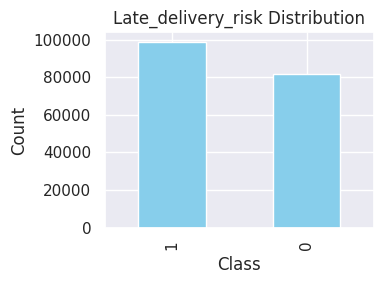

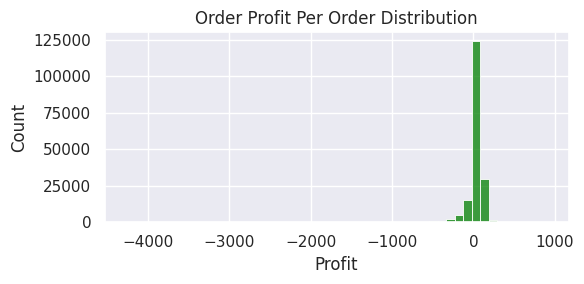

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme()

# Late_delivery_risk distribution (classification target)
if 'Late_delivery_risk' in df_clean.columns:
    plt.figure(figsize=(4,3))
    df_clean['Late_delivery_risk'].value_counts().plot(kind='bar', color='skyblue')
    plt.title('Late_delivery_risk Distribution')
    plt.xlabel('Class')
    plt.ylabel('Count')
    plt.tight_layout()
    plt.show()

# Order Profit (regression target)
if 'Order Profit Per Order' in df_clean.columns:
    plt.figure(figsize=(6,3))
    sns.histplot(df_clean['Order Profit Per Order'], bins=50, color='green')
    plt.title('Order Profit Per Order Distribution')
    plt.xlabel('Profit')
    plt.ylabel('Count')
    plt.tight_layout()
    plt.show()


Numeric Feature Distributions

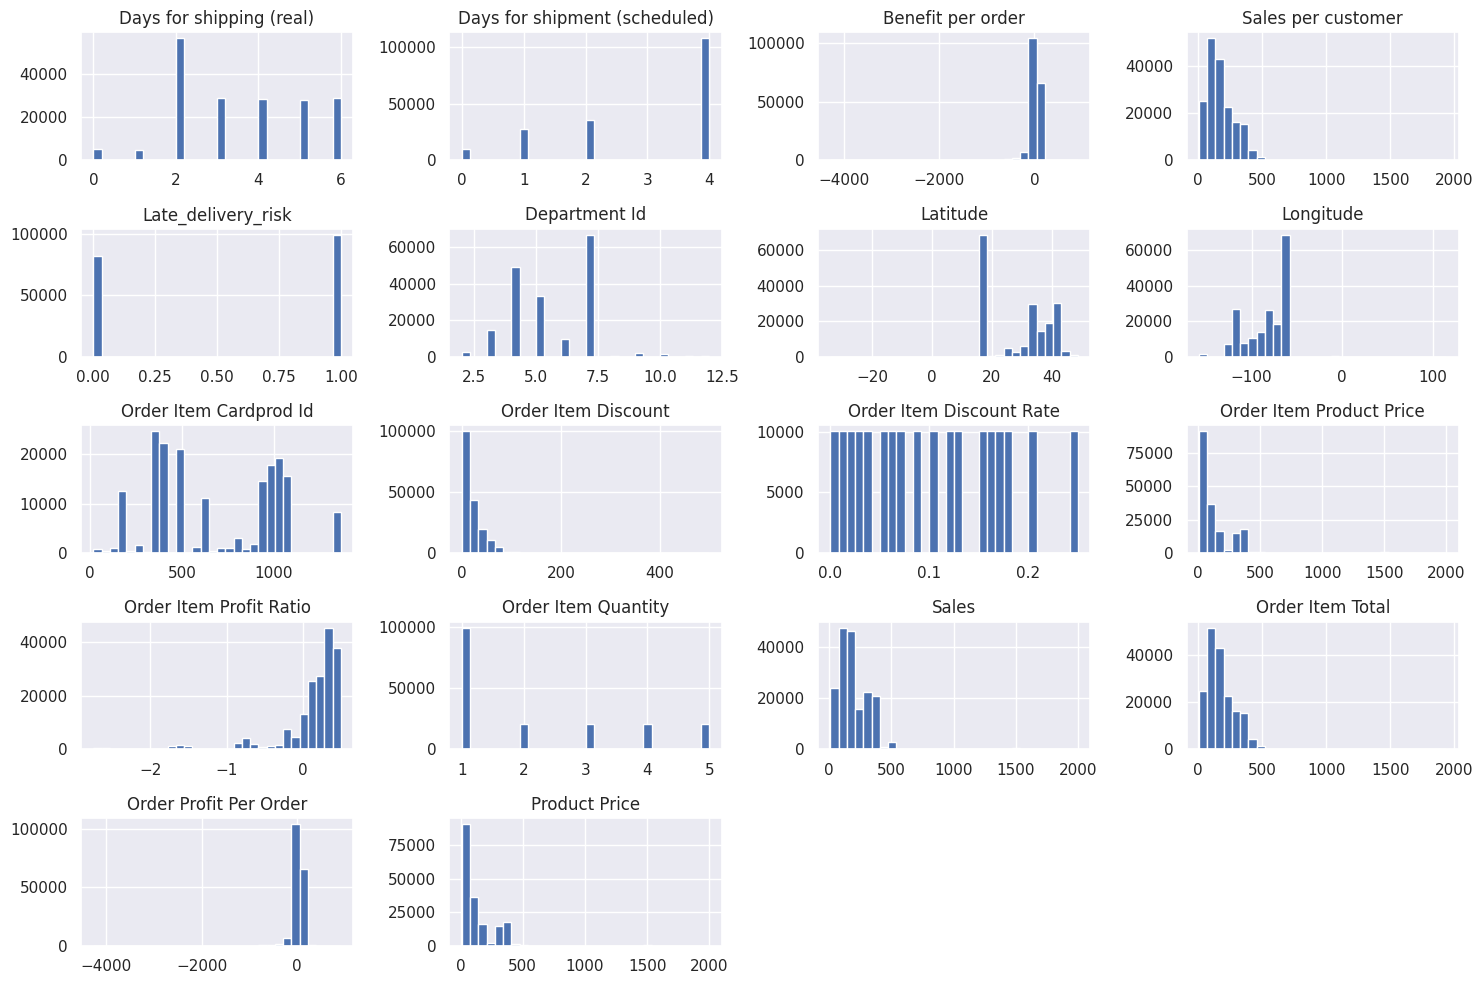

In [41]:
num_cols = df_clean.select_dtypes(include=['int64', 'float64']).columns.tolist()

df_clean[num_cols].hist(bins=30, figsize=(15,10), layout=(len(num_cols)//4 + 1, 4))
plt.tight_layout()
plt.show()


Correlation Peek

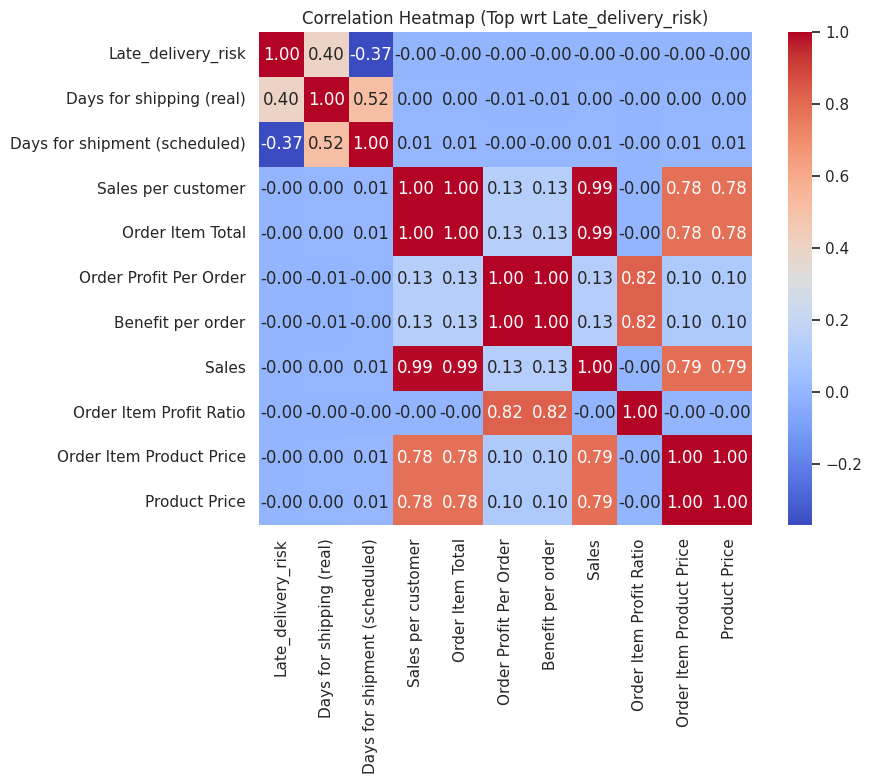

In [42]:
num_cols = df_clean.select_dtypes(include=['int64','float64']).columns.tolist()

if num_cols:
    corr = df_clean[num_cols].corr()
    target_for_heatmap = None
    for t in ['Late_delivery_risk', 'Order Profit Per Order', 'Product Price']:
        if t in corr.columns:
            target_for_heatmap = t
            break

    if target_for_heatmap:
        top_feats = corr[target_for_heatmap].drop(target_for_heatmap).abs().sort_values(ascending=False).head(10).index.tolist()
        cols_to_plot = [target_for_heatmap] + top_feats
        plt.figure(figsize=(10,8))
        sns.heatmap(df_clean[cols_to_plot].corr(), cmap='coolwarm', square=True, annot=True, fmt='.2f')
        plt.title(f"Correlation Heatmap (Top wrt {target_for_heatmap})")
        plt.tight_layout()
        plt.show()


In [44]:
# ==========================================
# Save the fully preprocessed dataset
# ==========================================

# Choose output path
output_csv = '/content/DataCoSupplyChainDataset_Cleaned.csv'

# Save CSV
df_clean.to_csv(output_csv, index=False)
print(f"✅ Cleaned dataset saved to: {output_csv}")




✅ Cleaned dataset saved to: /content/DataCoSupplyChainDataset_Cleaned.csv


In [45]:
# ===============================
#  preprocessing validation
# ===============================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme()

# Load the processed dataset
PROC = "/content/DataCoSupplyChainDataset_Cleaned.csv"
df_clean = pd.read_csv(PROC)

print("=== 1️⃣ Dataset Shape ===")
print(f"Rows: {df_clean.shape[0]}, Columns: {df_clean.shape[1]}\n")

print("=== 2️⃣ Column Types ===")
print(df_clean.dtypes.value_counts())
print(df_clean.dtypes)
print("\n")

print("=== 3️⃣ Missing Values Check ===")
missing_pct = (df_clean.isna().mean() * 100).round(2)
print(missing_pct[missing_pct > 0])
if missing_pct.sum() == 0:
    print("✅ No missing values remain.\n")
else:
    print("⚠️ Some columns still have missing values!\n")

print("=== 4️⃣ Duplicates Check ===")
dup_count = df_clean.duplicated().sum()
print(f"Duplicate rows: {dup_count}\n")
if dup_count == 0:
    print("✅ No duplicates remain.\n")
else:
    print("⚠️ Duplicates found!\n")

print("=== 5️⃣ Target Columns ===")
targets = ['Late_delivery_risk', 'Order Profit Per Order']
for t in targets:
    if t in df_clean.columns:
        print(f"✅ Target '{t}' exists and ready.")
    else:
        print(f"⚠️ Target '{t}' missing!")

print("\n=== 6️⃣ Check for Remaining Object Columns ===")
cat_cols = df_clean.select_dtypes(include=['object']).columns.tolist()
if not cat_cols:
    print("✅ No object columns remain; categorical features encoded.")
else:
    print(f"⚠️ Object columns still present: {cat_cols}")

print("\n=== 7️⃣ Numeric Summary ===")
num_cols = df_clean.select_dtypes(include=['int64','float64']).columns.tolist()
print(df_clean[num_cols].describe().T)

print("\n=== 8️⃣ Sample Correlation Peek ===")
if len(num_cols) > 1:
    corr = df_clean[num_cols].corr()
    print(corr.head(10))  # just show top 10 for brevity

print("\n=== 9️⃣ Quick Target Distribution Check ===")
if 'Late_delivery_risk' in df_clean.columns:
    print("Late_delivery_risk value counts:")
    print(df_clean['Late_delivery_risk'].value_counts())
if 'Order Profit Per Order' in df_clean.columns:
    print("\nOrder Profit Per Order statistics:")
    print(df_clean['Order Profit Per Order'].describe())

print("\n===  🔹 Preprocessing Validation Complete 🔹 ===")


=== 1️⃣ Dataset Shape ===
Rows: 180519, Columns: 168

=== 2️⃣ Column Types ===
bool       150
float64     12
int64        6
Name: count, dtype: int64
Days for shipping (real)           int64
Days for shipment (scheduled)      int64
Benefit per order                float64
Sales per customer               float64
Late_delivery_risk                 int64
                                  ...   
Order Status_PROCESSING             bool
Order Status_SUSPECTED_FRAUD        bool
Shipping Mode_Same Day              bool
Shipping Mode_Second Class          bool
Shipping Mode_Standard Class        bool
Length: 168, dtype: object


=== 3️⃣ Missing Values Check ===
Series([], dtype: float64)
✅ No missing values remain.

=== 4️⃣ Duplicates Check ===
Duplicate rows: 0

✅ No duplicates remain.

=== 5️⃣ Target Columns ===
✅ Target 'Late_delivery_risk' exists and ready.
✅ Target 'Order Profit Per Order' exists and ready.

=== 6️⃣ Check for Remaining Object Columns ===
✅ No object columns remain; categ